Please enter stock code and company name in the format: Stock Code,Company Name
Example: 000333,Midea
Press Enter (without typing) to finish input


Enter stock code and company name:  000333,Midea


Added: 000333 -> Midea


Enter stock code and company name:  000651,Gree


Added: 000651 -> Gree


Enter stock code and company name:  600690,Haier


Added: 600690 -> Haier


Enter stock code and company name:  



Analyzing data for: ['Midea', 'Gree', 'Haier']
Starting analysis for: ['000333', '000651', '600690']
Loading library list...
Done
Fetching data from WRDS...
Data successfully saved to Excel.


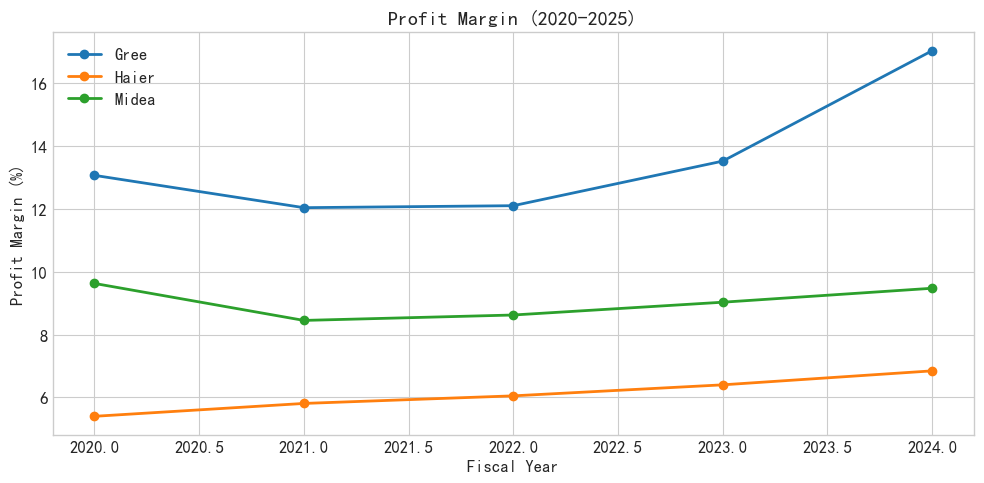

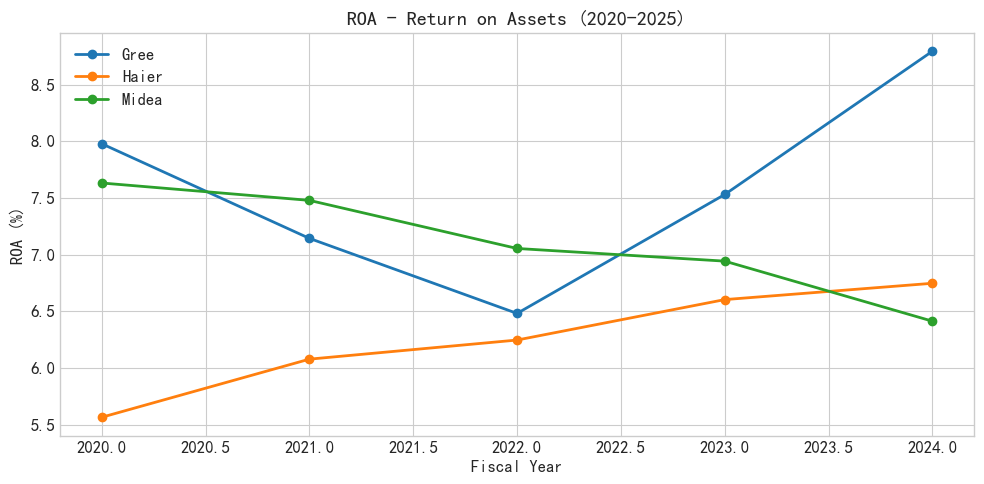

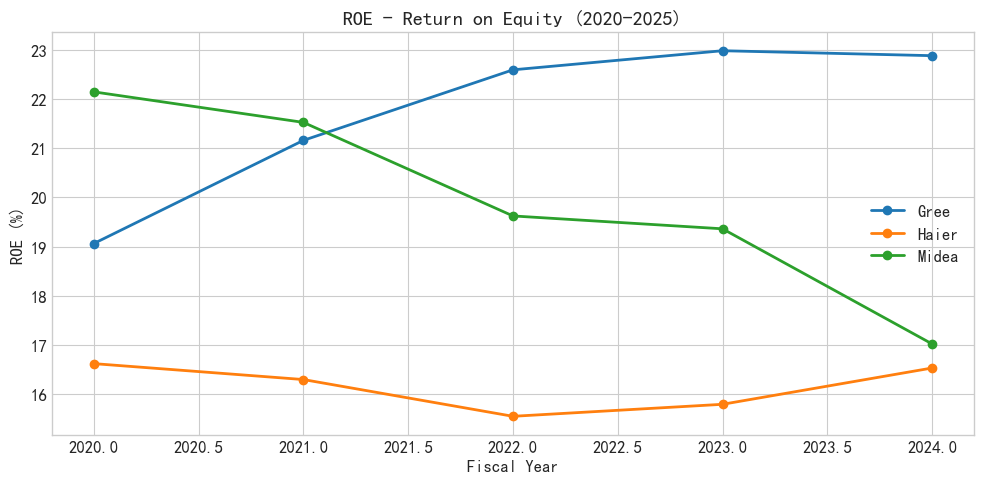

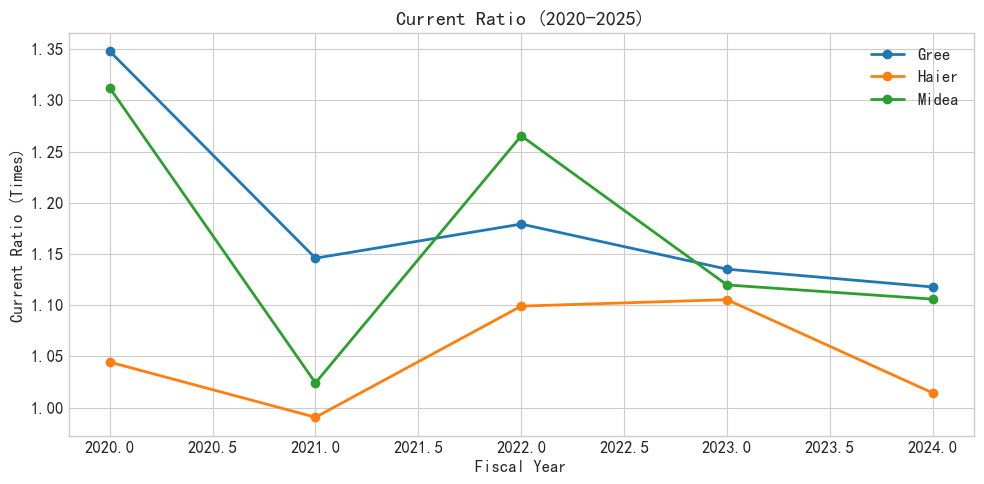

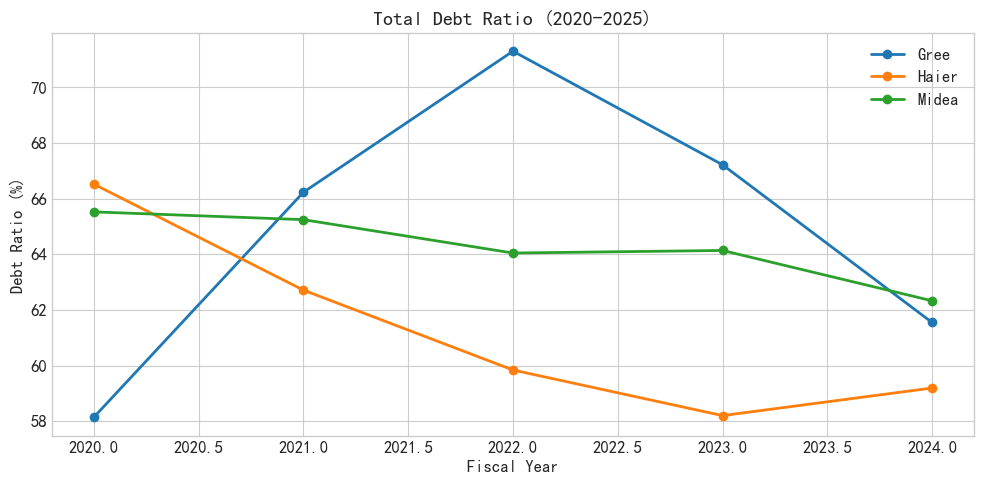

All charts generated successfully.


In [5]:
import wrds
import pandas as pd
import matplotlib.pyplot as plt
import sys

def financial_analysis(stock_code_map, username):
    print(f"Starting analysis for: {list(stock_code_map.keys())}")
    
    # 1. Database Connection (Using 'with' for auto-cleanup)
    db = wrds.Connection(wrds_username=username)

    # 2. Prepare Query
    stock_code_list = list(stock_code_map.keys())
    start_date = "2020-01-01"
    end_date = "2025-12-31"
    
    selected_columns = "stkcd, accper, typrep, b002000000, a001000000, a001100000, a003000000, b001100000, a002000000, a002100000"

    if len(stock_code_list) == 1:
        sql_query = f"""
        SELECT {selected_columns}
        FROM csmar.wrds_csmar_financial_master
        WHERE stkcd = '{stock_code_list[0]}'
        AND accper BETWEEN '{start_date}' AND '{end_date}'
        AND typrep = 'A'
        """
    else:
        sql_query = f"""
        SELECT {selected_columns}
        FROM csmar.wrds_csmar_financial_master
        WHERE stkcd IN {tuple(stock_code_list)}
        AND accper BETWEEN '{start_date}' AND '{end_date}'
        AND typrep = 'A'
        """
        
    print("Fetching data from WRDS...")
    raw_data = db.raw_sql(sql_query, date_cols=["accper"])
    db.close() # Close connection immediately after fetching data
        
    raw_data = raw_data.rename(columns={
        "b002000000": "Net Profit",
        "a001000000": "Total Assets",
        "a001100000": "Total Current Assets",
        "a003000000": "Equity",
        "b001100000": "Revenue",
        "a002000000": "Total Liabilities",
        "a002100000": "Total Current Liabilities"
    })

    required_cols = ['Net Profit', 'Total Assets', 'Total Current Assets', 'Equity', 'Revenue', 'Total Liabilities', 'Total Current Liabilities']
    
    # Check for missing columns
    missing_cols = [col for col in required_cols if col not in raw_data.columns]
    if missing_cols:
        print(f"Warning: Missing columns in data: {missing_cols}")
        return

    clean_data = raw_data.dropna(subset=required_cols).copy()
    clean_data = clean_data[clean_data['accper'].dt.month == 12]

    clean_data['stkcd'] = clean_data['stkcd'].astype(str)
    clean_data['company_name'] = clean_data['stkcd'].replace(stock_code_map)
    clean_data = clean_data.dropna(subset=['company_name'])

    if clean_data.empty:
        print("No data remaining after cleaning (check company codes).")
        return

    clean_data['fiscal_year'] = clean_data['accper'].dt.year

    # Calculate Ratios
    clean_data['ROA'] = (clean_data['Net Profit'] / clean_data['Total Assets']) * 100
    clean_data['ROE'] = (clean_data['Net Profit'] / clean_data['Equity']) * 100 
    clean_data['Net Profit Margin'] = (clean_data['Net Profit'] / clean_data['Revenue']) * 100 
    clean_data['Current Ratio'] = clean_data['Total Current Assets'] / clean_data['Total Current Liabilities'] 
    clean_data['Total Debt Ratio'] = (clean_data['Total Liabilities'] / clean_data['Total Assets']) * 100 

    final_cols = ['company_name', 'fiscal_year', 'ROA', 'ROE', 'Net Profit Margin', 'Current Ratio', 'Total Debt Ratio']
    final_data = clean_data[final_cols].sort_values(['company_name', 'fiscal_year'])

    # 5. Save to Excel
    final_data.to_excel('WRDS_Financial_Analysis_Results.xlsx', index=False)
    print("Data successfully saved to Excel.")

    # 6. Plotting
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams['font.size'] = 12
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'Arial'] 
    plt.rcParams['axes.unicode_minus'] = False

    def plot_financial_trend(data, ratio_col, title, ylabel, save_name):
        plt.figure(figsize=(10, 5))
        
        # Loop through companies actually present in the data
        companies_in_data = data['company_name'].unique()
        
        for company in companies_in_data:
            temp = data[data.company_name == company]
            if not temp.empty:
                plt.plot(temp.fiscal_year, temp[ratio_col], marker='o', label=company, linewidth=2)
        
        plt.title(title, fontweight='bold')
        plt.xlabel("Fiscal Year")
        plt.ylabel(ylabel)
        plt.legend()
        plt.tight_layout()
        plt.savefig(save_name, bbox_inches='tight', dpi=300)
        plt.show()
        plt.close()

    # Generate Charts (Fixed "Total debt ratio" to "Total Debt Ratio")
    plot_financial_trend(final_data, "Net Profit Margin", f"Profit Margin ({start_date[:4]}-{end_date[:4]})", "Profit Margin (%)", "Chart_1_Profit_Margin.png")
    plot_financial_trend(final_data, "ROA", f"ROA - Return on Assets ({start_date[:4]}-{end_date[:4]})", "ROA (%)", "Chart_2_ROA.png")
    plot_financial_trend(final_data, "ROE", f"ROE - Return on Equity ({start_date[:4]}-{end_date[:4]})", "ROE (%)", "Chart_3_ROE.png")
    plot_financial_trend(final_data, "Current Ratio", f"Current Ratio ({start_date[:4]}-{end_date[:4]})", "Current Ratio (Times)", "Chart_4_Current_Ratio.png")
    plot_financial_trend(final_data, "Total Debt Ratio", f"Total Debt Ratio ({start_date[:4]}-{end_date[:4]})", "Debt Ratio (%)", "Chart_5_Debt_Ratio.png")

    print("All charts generated successfully.")

if __name__ == "__main__":
    print("Please enter stock code and company name in the format: Stock Code,Company Name")
    print("Example: 000333,Midea")
    print("Press Enter (without typing) to finish input")
    
    stock_code_map = {}
    
    while True:
        user_input = input("Enter stock code and company name: ")
        if not user_input:
            break
        
        try:
            code, name = user_input.split(',')
            stock_code_map[code.strip()] = name.strip()
            print(f"Added: {code.strip()} -> {name.strip()}")
        except ValueError:
            print("Invalid format. Please use: Stock Code,Company Name")
    
    if not stock_code_map:
        print("No stock information entered, program exiting")
        sys.exit(1)
    
    print(f"\nAnalyzing data for: {list(stock_code_map.values())}")

    username = "yycc" 
    financial_analysis(stock_code_map, username)